<a href="https://colab.research.google.com/github/Rodrigoldarocha/An-lise-e-visualiza-o-do-Spotify/blob/main/An%C3%A1lise_e_visualiza%C3%A7%C3%A3o_do_Spotifyl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Projeto de Ciência de Dados: Previsão da Popularidade de Músicas

Este é um projeto que desenvolvi como parte do meu portfólio, pensado especialmente para estudantes iniciantes e intermediários em Python. A ideia é trabalhar no Google Colab utilizando um dataset inspirado nas características de músicas do Spotify.

O objetivo principal é prever a popularidade de uma música a partir de suas propriedades acústicas, aplicando técnicas de regressão. Dessa forma, além de praticar análise de dados e machine learning, consigo explorar um tema envolvente e próximo do nosso dia a dia: música.

## 📌 Visão Geral do Projeto

Tipo de problema: Regressão

Variável alvo: popularity

Ferramentas: Python, Pandas, Matplotlib, Seaborn, Scikit-learn

Ambiente: Google Colab

# 1️⃣ Carregamento e Exploração Inicial dos Dados

In [ ]:
import pandas as pd # Manipulação de dados tabulares
import numpy as np # Operações numéricas
import matplotlib.pyplot as plt # Visualizações básicas
import seaborn as sns # Visualizações estatísticas

# 📂 Carregamento do dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/spotify-analysis-and-visualization")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spotify-analysis-and-visualization' dataset.
Path to dataset files: /kaggle/input/spotify-analysis-and-visualization


In [ ]:
import os
df = pd.read_csv(os.path.join(path, 'spotify_analysis_dataset.csv'))

# 👀 Visualização inicial

In [ ]:
df.head()

,track_id,track_name,artist,album,release_date,duration_ms,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,TRK1000,Song 0,Artist 7,Album 3,2010-01-01,240151,70,0.037,0.349,-2.87,0.522,0.616,0.931,0.947,0.353,110.14
1,TRK1001,Song 1,Artist 4,Album 5,2010-01-02,253767,58,0.610,0.726,-22.87,0.770,0.635,0.858,0.986,0.584,75.90
2,TRK1002,Song 2,Artist 13,Album 19,2010-01-03,244375,85,0.503,0.897,-1.33,0.216,0.045,0.429,0.753,0.078,154.02
3,TRK1003,Song 3,Artist 11,Album 7,2010-01-04,299262,27,0.051,0.887,-1.46,0.623,0.375,0.751,0.376,0.974,132.84
4,TRK1004,Song 4,Artist 8,Album 9,2010-01-05,256330,65,0.279,0.780,-5.88,0.085,0.626,0.755,0.084,0.986,168.12


# 📐 Dimensão do dataset

In [ ]:
df.shape

(50, 16)

# 🧾 Tipos de dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50 non-null     object 
 1   track_name        50 non-null     object 
 2   artist            50 non-null     object 
 3   album             50 non-null     object 
 4   release_date      50 non-null     object 
 5   duration_ms       50 non-null     int64  
 6   popularity        50 non-null     int64  
 7   danceability      50 non-null     float64
 8   energy            50 non-null     float64
 9   loudness          50 non-null     float64
 10  speechiness       50 non-null     float64
 11  acousticness      50 non-null     float64
 12  instrumentalness  50 non-null     float64
 13  liveness          50 non-null     float64
 14  valence           50 non-null     float64
 15  tempo             50 non-null     float64
dtypes: float64(9), int64(2), object(5)
memory usag

# ❓ Verificação de valores ausentes

In [ ]:
df.isnull().sum()

,0
track_id,0
track_name,0
artist,0
album,0
release_date,0
duration_ms,0
popularity,0
danceability,0
energy,0
loudness,0


# 2️⃣ Análise Exploratória de Dados (EDA)

## 🎯 Por que EDA é importante?

A EDA nos ajuda a:

Entender distribuições

Identificar padrões

Detectar outliers

Guiar decisões de modelagem

## 📊 Estatísticas descritivas

In [ ]:
df.describe()

,duration_ms,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,212726.100000,50.320000,0.47420,0.506000,-17.696000,0.455460,0.496620,0.517740,0.529320,0.607080,126.094000
std,47725.482111,27.528419,0.29023,0.299962,11.567047,0.278252,0.304199,0.311123,0.321099,0.305826,39.179744
min,128392.000000,0.000000,0.01700,0.005000,-38.780000,0.014000,0.018000,0.011000,0.011000,0.026000,62.040000
25%,170575.250000,27.500000,0.23850,0.238750,-26.265000,0.224000,0.217500,0.299500,0.278000,0.377250,90.762500
50%,227562.500000,55.500000,0.50750,0.572500,-17.035000,0.473500,0.560500,0.527500,0.541000,0.645000,126.590000
75%,246702.250000,69.750000,0.67650,0.725000,-7.607500,0.687000,0.747000,0.791500,0.846000,0.861250,152.945000
max,299262.000000,96.000000,0.98600,0.973000,-0.400000,0.976000,0.991000,0.987000,0.993000,1.000000,197.200000


# 📈 Distribuição da popularidade

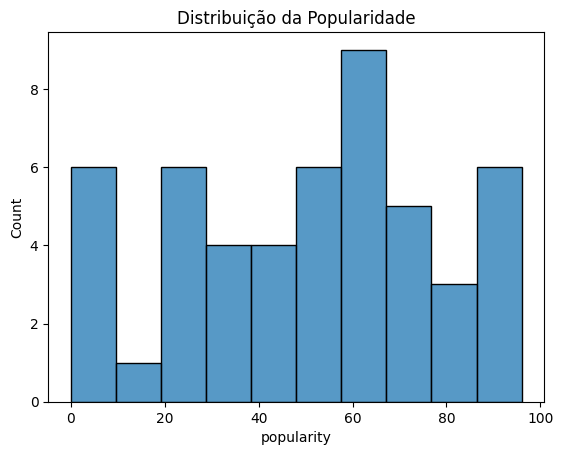

In [ ]:
plt.figure()
sns.histplot(df['popularity'], bins=10)
plt.title('Distribuição da Popularidade')
plt.show()

## 🔗 Correlação entre variáveis numéricas

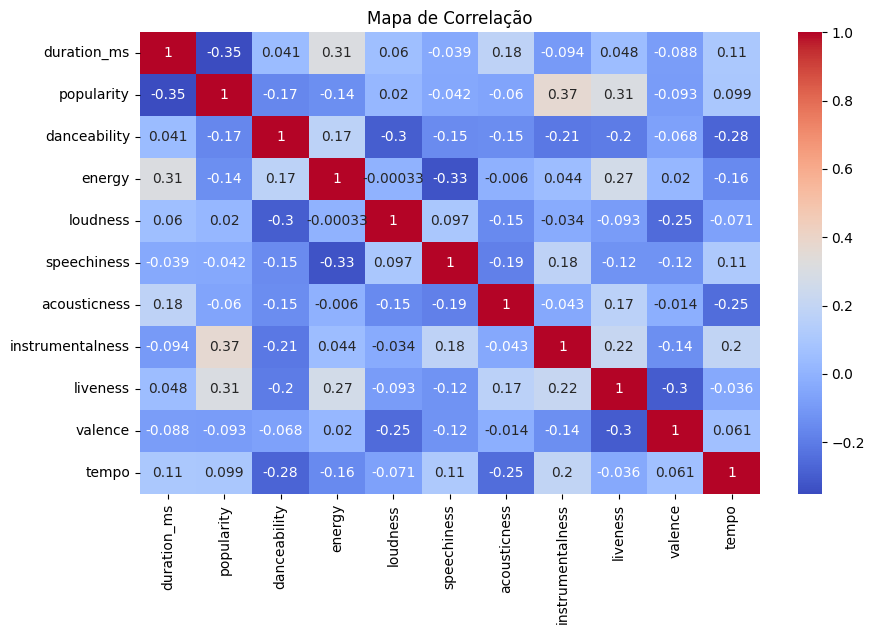

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

# 3️⃣ Preparação dos Dados

## 🧠 Objetivo da etapa

Modelos de machine learning não lidam bem com dados brutos. Precisamos:

Selecionar variáveis relevantes

Converter categorias

Normalizar escalas

## 🧹 Seleção de colunas

Vamos remover colunas textuais que não ajudam na previsão:

In [ ]:
X = df.drop(columns=['track_id', 'track_name', 'artist', 'album', 'release_date', 'popularity'])
y = df['popularity']

# ⚖️ Padronização dos dados

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✂️ Divisão treino/teste

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42
)

# 4️⃣ Construção do Modelo Preditivo

## 🤖 Escolha do modelo

Vamos usar Regressão Linear, pois:

É simples

Interpretável

Ideal para projetos iniciais

# 🏗️ Treinamento do modelo

In [ ]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 🔮 Previsões

In [ ]:
y_pred = model.predict(X_test)

# 5️⃣ Avaliação do Modelo

## 📏 Métricas de regressão

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print('MAE:', mae)
print('RMSE:', rmse)
print('R²:', r2)

MAE: 25.11396861828921
RMSE: 30.048523749279706
R²: 0.31279347623391096


# 📉 Visualização: valores reais vs previstos

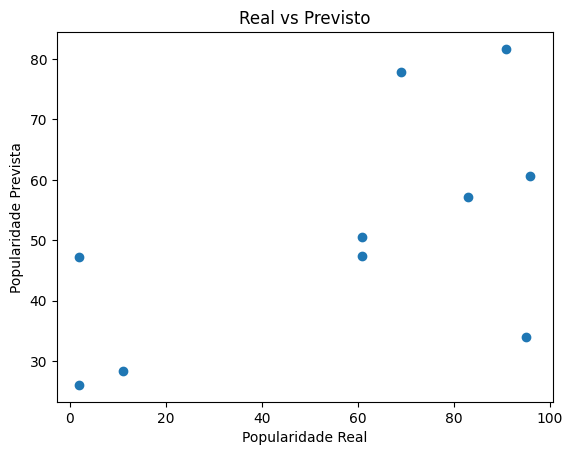

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel('Popularidade Real')
plt.ylabel('Popularidade Prevista')
plt.title('Real vs Previsto')
plt.show()